In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [628]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [629]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
# from datetime import datetime, timezone

from data.coindesk import CoinDesk

In [633]:
coindesk_data = CoinDesk()

tickers = ["ETH-EUR", "BNB-EUR"]
points = 5 * 365 # number of datapoints

# df = coindesk_data.get_OHLC('ETH-EUR', points)

secs = coindesk_data.get_historical(tickers, points)
secs

{'ETH-EUR':      UNIT   TIMESTAMP         OPEN         HIGH          LOW        CLOSE  \
 0     DAY  1613865600  1583.968638  1631.262368  1562.039540  1598.068381   
 1     DAY  1613952000  1598.068381  1598.777549  1283.738711  1463.956702   
 2     DAY  1614038400  1463.956702  1466.332525  1132.822423  1299.006935   
 3     DAY  1614124800  1299.006935  1410.330950  1238.686169  1337.820187   
 4     DAY  1614211200  1337.820187  1373.560817  1204.148237  1214.997432   
 ...   ...         ...          ...          ...          ...          ...   
 1820  DAY  1771113600  1758.102466  1773.195736  1626.053732  1658.543362   
 1821  DAY  1771200000  1658.543362  1706.966566  1635.243589  1687.076645   
 1822  DAY  1771286400  1687.076645  1700.496860  1639.572387  1680.762174   
 1823  DAY  1771372800  1680.762174  1729.005275  1624.191847  1659.946614   
 1824  DAY  1771459200  1659.946614  1663.541397  1655.238635  1659.827171   
 
                           DATE  
 0    2021-02-21 

<h5 style="color:red">Handle pagination</h5>

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_47411/894544740.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


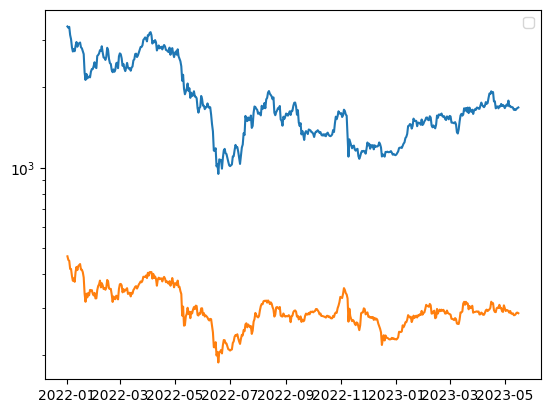

In [647]:
for ticker in tickers:
    plt.plot(secs[ticker]['DATE'], secs[ticker]['CLOSE'])

plt.yscale('log')
plt.legend()

In [646]:
# filter data to compare it to research df
secs['ETH-EUR'] = secs['ETH-EUR'][(secs['ETH-EUR']['DATE'] > pd.to_datetime('2022-01-01', utc=True)) &
                                  (secs['ETH-EUR']['DATE'] < pd.to_datetime('2023-05-17', utc=True))]
secs['BNB-EUR'] = secs['BNB-EUR'][(secs['BNB-EUR']['DATE'] > pd.to_datetime('2022-01-01', utc=True)) &
                                  (secs['BNB-EUR']['DATE'] < pd.to_datetime('2023-05-17', utc=True))]

## NOTE
`bnb` as the independent asset doesn't make as much sense as viceversa, thus it is good to think this logically and try both directions

In [ ]:
dates = secs['ETH-EUR']['DATE']

eth = secs['ETH-EUR']['CLOSE']
bnb = secs['BNB-EUR']['CLOSE']

# plt.plot(dates, x)
# plt.plot(dates, y)
# plt.yscale('log')

stat, pval, crit = coint(eth,  bnb, trend = 'c', maxlag = 1, autolag = None)

print("Engle–Granger CADF via coint")
print("stat:", stat)
print("p-value:", pval)
print("crit:", crit)

Engle–Granger CADF via coint
stat: -3.185474567396312
p-value: 0.07239070995389837
crit: [-3.91852234 -3.34840209 -3.05296032]


In [655]:
X = sm.add_constant(bnb)

model = sm.OLS(eth, X).fit()

h_ratio = model.params['CLOSE']
h_ratio

np.float64(10.841522353842405)

<Axes: >

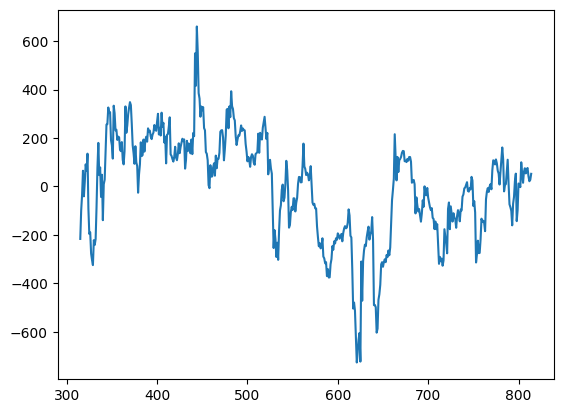

In [656]:
model.resid.plot()

In [807]:
p = np.column_stack([bnb, eth])

jres = coint_johansen(p, 0, 1)

print("Trace statistics:", jres.trace_stat)
print("Trace crit values (90, 95, 99%):\n", jres.trace_stat_crit_vals)

print("Max-eig statistics:", jres.max_eig_stat)
print("Max-eig crit values (90, 95, 99%):\n", jres.max_eig_stat_crit_vals)

Trace statistics: [21.92190814  5.1877368 ]
Trace crit values (90, 95, 99%):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max-eig statistics: [16.73417134  5.1877368 ]
Max-eig crit values (90, 95, 99%):
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [808]:
print("Eigenvalues:")
print(jres.eig)

print("Eigenvectors:")
print(jres.evec)

Eigenvalues:
[0.03304445 0.01036307]
Eigenvectors:
[[ 0.05000583 -0.0250018 ]
 [-0.0031924   0.00354319]]


> There is no stationarity, but there can still be short-term mean-reversion

Testing and determining mean-reversion relationship

In [ ]:
evec = jres.evec[:, 0]

# setting bnb B to 1
jbeta = evec[1] / evec[0]
res = bnb - jbeta * eth # or spread
# res = res - np.mean(res)
adfuller(res, 1)

(np.float64(-3.067833494444601),
 np.float64(0.029027060890629713),
 1,
 498,
 {'1%': np.float64(-3.4435494520411605),
  '5%': np.float64(-2.8673612117611267),
  '10%': np.float64(-2.5698704830567247)},
 np.float64(4070.302010434483))

In [823]:
jbeta = evec[0] / evec[1]
res = eth - jbeta * bnb # or spread
# res = res - np.mean(res)
adfuller(res, 1)

(np.float64(-3.067833494444623),
 np.float64(0.02902706089062797),
 1,
 498,
 {'1%': np.float64(-3.4435494520411605),
  '5%': np.float64(-2.8673612117611267),
  '10%': np.float64(-2.5698704830567247)},
 np.float64(6810.663123313095))

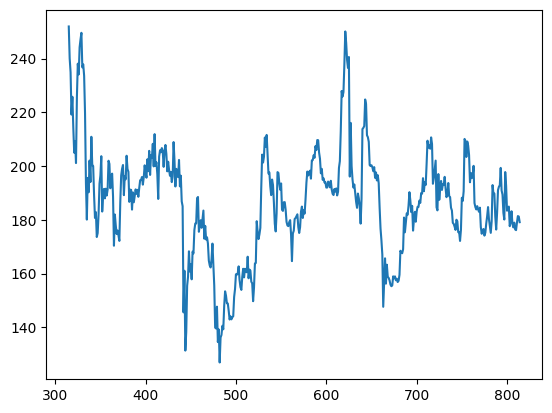

In [685]:
eig_ratio = jres.evec[1, 0] / jres.evec[0, 0]
spred = bnb + eth * eig_ratio

plt.plot(spred)

In [686]:
lookback = 20 # placeholder

h_ratio = np.full((len(eth), 1), np.nan)

for t in range(lookback, len(eth) + 1):
    yn = bnb[t - lookback : t]
    xn = eth[t - lookback : t]
    X = sm.add_constant(xn)
    model = sm.OLS(yn, X).fit()
    h_ratio[t - 1, :] = model.params['CLOSE']

units = np.column_stack([np.ones(len(eth)), -h_ratio])

portfolio = np.sum(units * p, axis = 1)


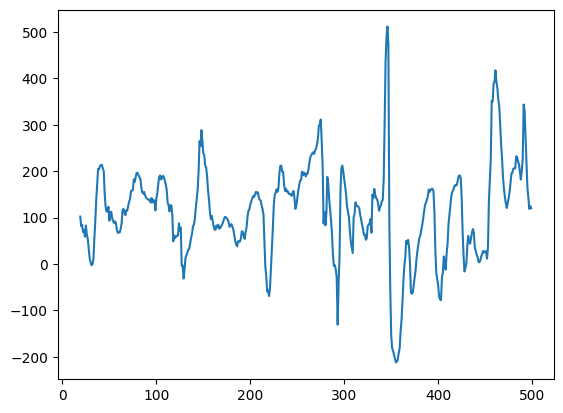

In [687]:
spread = bnb.to_numpy().reshape(-1, 1) - eth.to_numpy().reshape(-1, 1) * h_ratio
plt.plot(spread) # or plt.plot(portfolio)

In [688]:
ma = pd.Series(portfolio).rolling(lookback).mean()
st = pd.Series(portfolio).rolling(lookback).std()

zscore = (portfolio - ma) / st

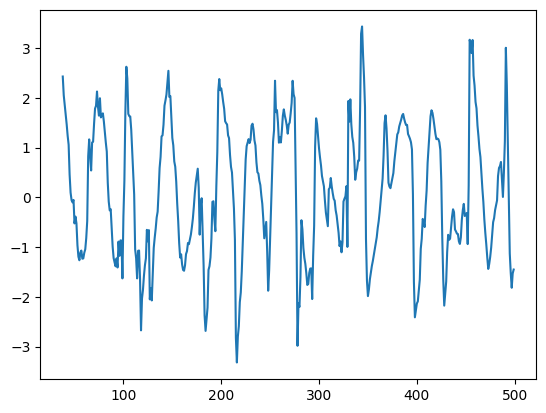

In [721]:
# len(zscore[19:39])
# zscore[:21]

plt.plot(zscore)

## Implementation of multiple strategies; scroll down for result comparison

In [690]:
strategies = {}

In [691]:
position = -zscore

position = position.values.reshape(len(position), -1) # reshape
# print(position[:38])

position = (position * units) * p

position = pd.DataFrame(position, index = secs[tickers[0]]['DATE'], columns = tickers)

# position[38:]

In [692]:
y2 = pd.DataFrame(p, index = secs[tickers[0]]['DATE'], columns = tickers)
chng = (y2 - y2.shift(1)) / y2.shift(1)
# type(chng), type(y2.pct_change())

PnL = (position.shift(1) * chng).sum(axis = 1)

ret = PnL / (abs(position.shift(1))).sum(axis = 1)

In [693]:
ret_clean = ret[~np.isnan(ret)]

APR = np.prod(1 + ret_clean) ** (252 / len(ret_clean)) - 1

APR_simple = 252 * ret_clean.mean()

SR = (ret_clean.mean() / ret_clean.std()) * np.sqrt(252)

strategies['limitless'] = {
    "APR": APR,
    "Sharpe": SR
}

print(f'APR: {APR:.4f}')
print(f'Simple APR: {APR_simple:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: 0.1086
Simple APR: 0.1255
Sharpe: 0.5909


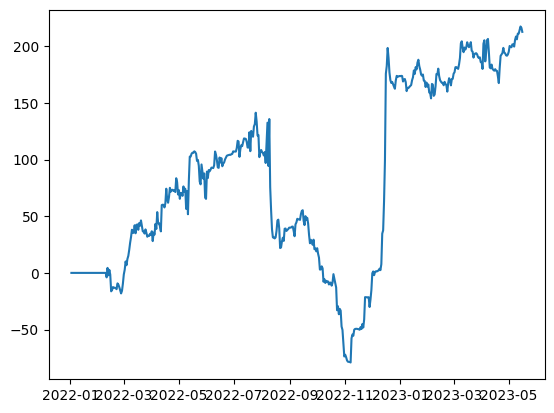

In [694]:
equity = (1 + ret.fillna(0.0)).cumprod()
PnL_cum = PnL.fillna(0.0).cumsum()

# plt.plot(equity.index, equity.values)
plt.plot(PnL_cum.index, PnL_cum.values)


In [798]:
entry_zscore = 1
exit_zscore = 0

long_entry = zscore < -entry_zscore
long_exit = zscore >= -exit_zscore

short_entry = zscore > entry_zscore
short_exit = zscore <= exit_zscore

units_long = pd.Series(np.nan, index = zscore.index)
units_long[0] = 0
units_long[long_entry] = 1
units_long[long_exit] = 0
units_long = units_long.ffill()

units_short = pd.Series(np.nan, index = zscore.index)
units_short[0] = 0
units_short[short_entry] = -1
units_short[short_exit] = 0
units_short = units_short.ffill()

position = units_long + units_short

In [799]:
position = position.values.reshape(len(position), -1) # reshape
# print(position[:38])

position = (position * units) * p

position = pd.DataFrame(position, index = secs[tickers[0]]['DATE'], columns = tickers)

In [800]:
y2 = pd.DataFrame(p, index = secs[tickers[0]]['DATE'], columns = tickers)
chng = (y2 - y2.shift(1)) / y2.shift(1)
# type(chng), type(y2.pct_change())

PnL = (position.shift(1) * chng).sum(axis = 1)

ret = PnL / (abs(position.shift(1))).sum(axis = 1)

In [801]:
ret_clean = ret[~np.isnan(ret)]

APR = np.prod(1 + ret_clean) ** (252 / len(ret_clean)) - 1

APR_simple = 252 * ret_clean.mean()

SR = (ret_clean.mean() / ret_clean.std()) * np.sqrt(252)

strategies['ma'] = {
    "APR": APR,
    "Sharpe": SR
}

print(f'APR: {APR:.4f}')
print(f'Simple APR: {APR_simple:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: 0.0696
Simple APR: 0.0889
Sharpe: 0.4254


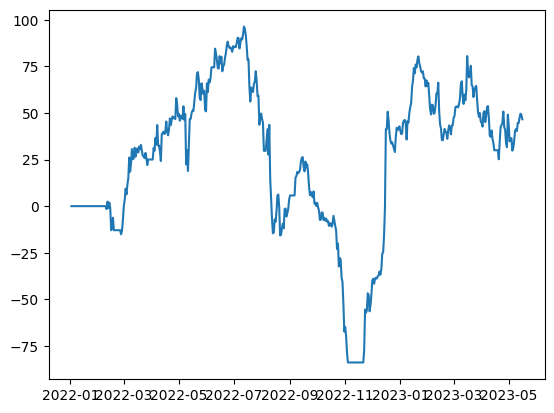

In [735]:
equity = (1 + ret.fillna(0.0)).cumprod()
PnL_cum = PnL.fillna(0.0).cumsum()

# plt.plot(equity.index, equity.values)
plt.plot(PnL_cum.index, PnL_cum.values)

In [767]:
X = np.column_stack((eth, np.ones_like(eth)))
y = bnb

delta = 0.0001

yhat = np.full(len(eth), np.nan)

e = np.full(len(eth), np.nan)
Q = np.full(len(eth), np.nan)

P = np.zeros((2, 2)) # this represents R(t|t)

beta = np.full((2, len(bnb)), np.nan)

Vw = delta / (1 - delta) * np.diag(np.ones(2))
Ve = 0.001

In [784]:
# initial values
beta[:, 0] = 0
R = np.zeros((2, 2))

for t in range(len(eth)):
    
    # prediction step
    if t > 0:
        beta[:, t] = beta[:, t - 1]
        R = P + Vw
    
    
    yhat[t] = X[t, :] @ beta[:, t]

    Q[t] = X[t, :] @ R @ X[t, :] + Ve
    
    e[t] = y.iloc[t] - yhat[t]
    K = R @ X[t, :] / Q[t]
    
    beta[:, t] = beta[:, t] + K * e[t]

    P = R - np.outer(K, X[t]) @ R

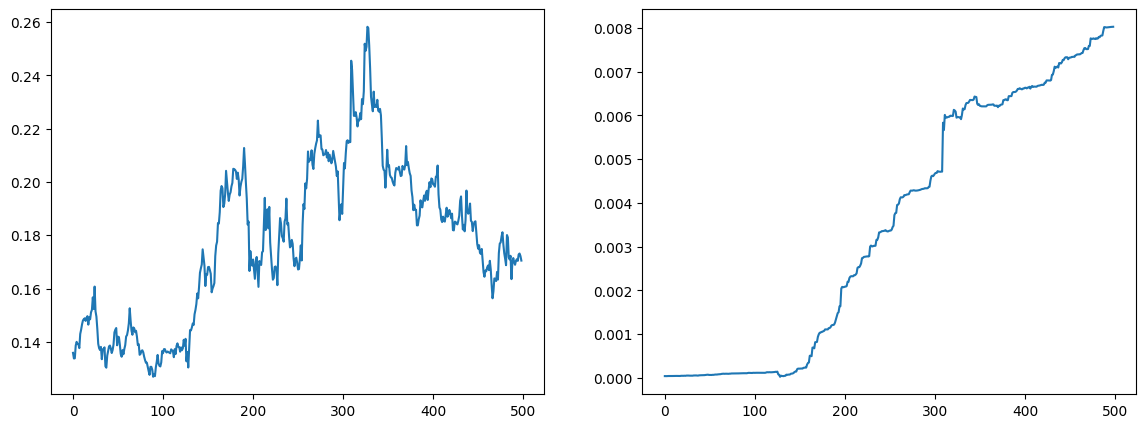

In [785]:
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

ax[0].plot(beta[0, 1:])
ax[1].plot(beta[1, 1:])

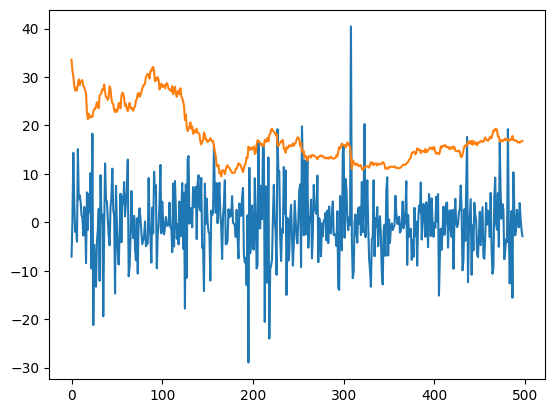

In [786]:
plt.plot(e[2:])
plt.plot(np.sqrt(np.abs(Q))[2:])

In [806]:
long_entry = e < - np.sqrt(Q)
long_exit = e > - np.sqrt(Q)

short_entry = e > np.sqrt(Q)
short_exit = e < np.sqrt(Q)

units_long = pd.Series(np.nan, index = zscore.index)
units_long[0] = 0
units_long[long_entry] = 1
units_long[long_exit] = 0
units_long = units_long.ffill()

units_short = pd.Series(np.nan, index = zscore.index)
units_short[0] = 0
units_short[short_entry] = -1
units_short[short_exit] = 0
units_short = units_short.ffill()

position = units_long + units_short

In [794]:
# type(beta[0, :]), type(h_ratio)
# h_ratio, beta[0, :]
# h_ratio.shape, beta[0, :].shape
# beta[0, :]

In [803]:
position = position.values.reshape(len(position), -1) # reshape
# print(position[:38])

kalman_units = np.column_stack([np.ones(len(bnb)), -beta[0, :]])
position = position * units * p

position = pd.DataFrame(position, index = secs[tickers[0]]['DATE'], columns = tickers)

In [804]:
y2 = pd.DataFrame(p, index = secs[tickers[0]]['DATE'], columns = tickers)
chng = (y2 - y2.shift(1)) / y2.shift(1)
# type(chng), type(y2.pct_change())

PnL = (position.shift(1) * chng).sum(axis = 1)

ret = PnL / (abs(position.shift(1))).sum(axis = 1)

In [805]:
ret_clean = ret[~np.isnan(ret)]

APR = np.prod(1 + ret_clean) ** (252 / len(ret_clean)) - 1

APR_simple = 252 * ret_clean.mean()

SR = (ret_clean.mean() / ret_clean.std()) * np.sqrt(252)

strategies['kalman'] = {
    "APR": APR,
    "Sharpe": SR
}

print(f'APR: {APR:.4f}')
print(f'Simple APR: {APR_simple:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: -0.0990
Simple APR: -0.0574
Sharpe: -0.1817


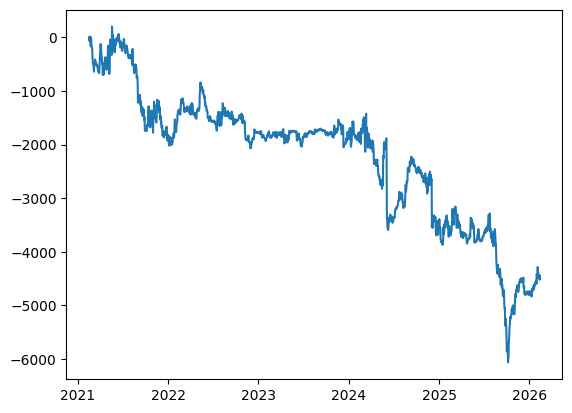

In [612]:
equity = (1 + ret.fillna(0.0)).cumprod()
PnL_cum = PnL.fillna(0.0).cumsum()

# plt.plot(equity.index, equity.values)
plt.plot(PnL_cum.index, PnL_cum.values)

In [615]:
pd.DataFrame(strategies).T.astype(float).sort_values("Sharpe", ascending=False)

,APR,Sharpe
kalman,-0.161735,-0.483604
limitless,-0.174515,-0.592436
ma,-0.210175,-0.758472


/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_47411/894544740.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


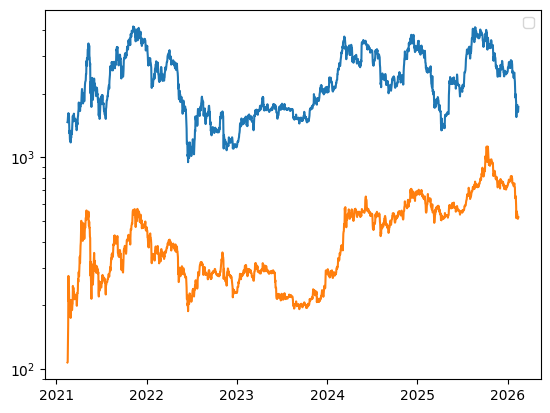

In [ ]:
for ticker in tickers:
    plt.plot(secs[ticker]['DATE'], secs[ticker]['CLOSE'])

plt.yscale('log')
plt.legend()

# Notes

> Ensure `shifts()` are correct
5. Read `Hudson Trading` book

6. Fine-tune hyperparameters (ie. `lookback`)
    - Extremely important! Especially if stationarity is somewhat achieved.
7. > Why Kalman filter works worse than bollinger bands?
8. Explore Ichimoku cloud